<center><h1> Projeto de Machine Learning </h1><center>
<center><h1>Previsão de Chuvas na Austrália</h1><center>

------------------------------------------------
<center>Eduardo Selber, Henrique Badin e Luca Caruso<center>

# Introdução

O clima exerce uma forte influência em diversas atividades humanas, desde a agricultura até o cotidiano das pessoas. Com o avanço das tecnologias, novas ferramentas de análise e previsão climática têm sido desenvolvidas. No entanto, prever chuvas de forma precisa, especialmente em regiões com grandes variações climáticas, como a Austrália, ainda representa um grande desafio.

A previsão de chuvas depende de uma complexa interação entre fatores atmosféricos, padrões de vento e características regionais. Isso torna a modelagem climática uma ferramenta essencial, não apenas para a agricultura, onde a distribuição das chuvas impacta as colheitas, mas também em outros setores da sociedade, como por exemplo na gestão de recursos hídricos, que são fundamentais para garantir o abastecimento de água em regiões propensas à seca.

Diante desse cenário, o presente estudo tem como objetivo analisar as variáveis que afetam a ocorrência de chuvas na Austrália e desenvolver um modelo de Machine Learning capaz de prever se irá chover no dia seguinte. Para isso, utilizaremos um conjunto de dados que contém informações meteorológicas coletadas em diversas estações de medição distribuídas pelo território australiano ao longo dos anos.

# Preparando o ambiente

In [1]:
#Importando as bibliotecas
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sweetviz as sv
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
import os


# EDA - Exploratory Data Analysis

Leitura dos dados e análise inicial

In [7]:
# Verificando o diretório atual
current_directory = os.getcwd()
# Listando os arquivos no diretório de dados
data_directory = os.path.join(current_directory, '..', 'data')

# Carregando o dataset
df = pd.read_csv('data/weatherAUS.csv')
df

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


### Analisando os tipos de dados das colunas do dataset e tamanho do dataset

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

Analisando os tipos de dados identificamos que os dados se dividem em **duas categorias**:
- **Categóricos** -  Identificados pelo tipo ***object**
- **Numéricos** - Identificados pelo tipo **float64**

O Dataset também conta com **145460** linhas e **23 colunas**, sendo elas:
- **Date** - A data da observação (formato: yyyy-mm-dd)
- **Location** - A localização da estação meteorológica (Nome da cidade - string)
- **MinTemp** - A temperatura mínima em graus Celsius (float)
- **MaxTemp** - A temperatura máxima em graus Celsius  (float)
- **Rainfall** - A quantidade de chuva medida em mm (float)
- **Evaporation** - A taxa de evaporação medida em mm (float)
- **Sunshine** - O número de horas de sol (float)
- **WindGustDir** - A direção da rajada de vento mais forte (string)
- **WindGustSpeed** - A velocidade (em km/h) da rajada de vento mais forte (float)
- **WindDir9am** - A direção do vento às 9am (string)
- **WindDir3pm** - A direção do vento às 3pm (string)
- **WindSpeed9am** - A velocidade do vento às 9am (em km/h) (float)
- **WindSpeed3pm** - A velocidade do vento às 3pm (em km/h) (float)
- **Humidity9am** - A umidade relativa às 9am (em %) (float)
- **Humidity3pm** - A umidade relativa às 3pm (em %) (float)
- **Pressure9am** - A pressão atmosférica reduzida ao nível do mar às 9am (em hpa) (float)
- **Pressure3pm** - A pressão atmosférica reduzida ao nível do mar às 3pm (em hpa) (float)
- **Cloud9am** - A fração de cobertura de nuvens às 9am (em oitavos) (float)
- **Cloud3pm** - A fração de cobertura de nuvens às 3pm (em oitavos) (float)
- **Temp9am** - A temperatura às 9am em graus Celsius (float)
- **Temp3pm** - A temperatura às 3pm em graus Celsius (float)
- **RainToday** - Se choveu (precipitação acima de 1mm) ou não (string)
- **RainTomorrow** - A variável alvo. Se choverá ou não amanhã (string)

### Analisando dados vazios no dataset

In [9]:
df.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

Como podemos ver, com exceção da *Data* e da *Localização* todos os dados apresentam uma quantidade significativa de dados ausentes. É necessário analisar individualmente cada um deles para entender qual o tratamento apropriado

### Analisando métricas estatísticas dos dados

In [10]:
# Verificando as métricas do dataset
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MinTemp,143975.0,12.194034,6.398495,-8.5,7.6,12.0,16.9,33.9
MaxTemp,144199.0,23.221348,7.119049,-4.8,17.9,22.6,28.2,48.1
Rainfall,142199.0,2.360918,8.478060,0.0,0.0,0.0,0.8,371.0
Evaporation,82670.0,5.468232,4.193704,0.0,2.6,4.8,7.4,145.0
Sunshine,75625.0,7.611178,3.785483,0.0,4.8,8.4,10.6,14.5
WindGustSpeed,135197.0,40.035230,13.607062,6.0,31.0,39.0,48.0,135.0
WindSpeed9am,143693.0,14.043426,8.915375,0.0,7.0,13.0,19.0,130.0
WindSpeed3pm,142398.0,18.662657,8.809800,0.0,13.0,19.0,24.0,87.0
Humidity9am,142806.0,68.880831,19.029164,0.0,57.0,70.0,83.0,100.0
Humidity3pm,140953.0,51.539116,20.795902,0.0,37.0,52.0,66.0,100.0


## Visualizando a distribução dos dados
#### Variáveis Numéricas

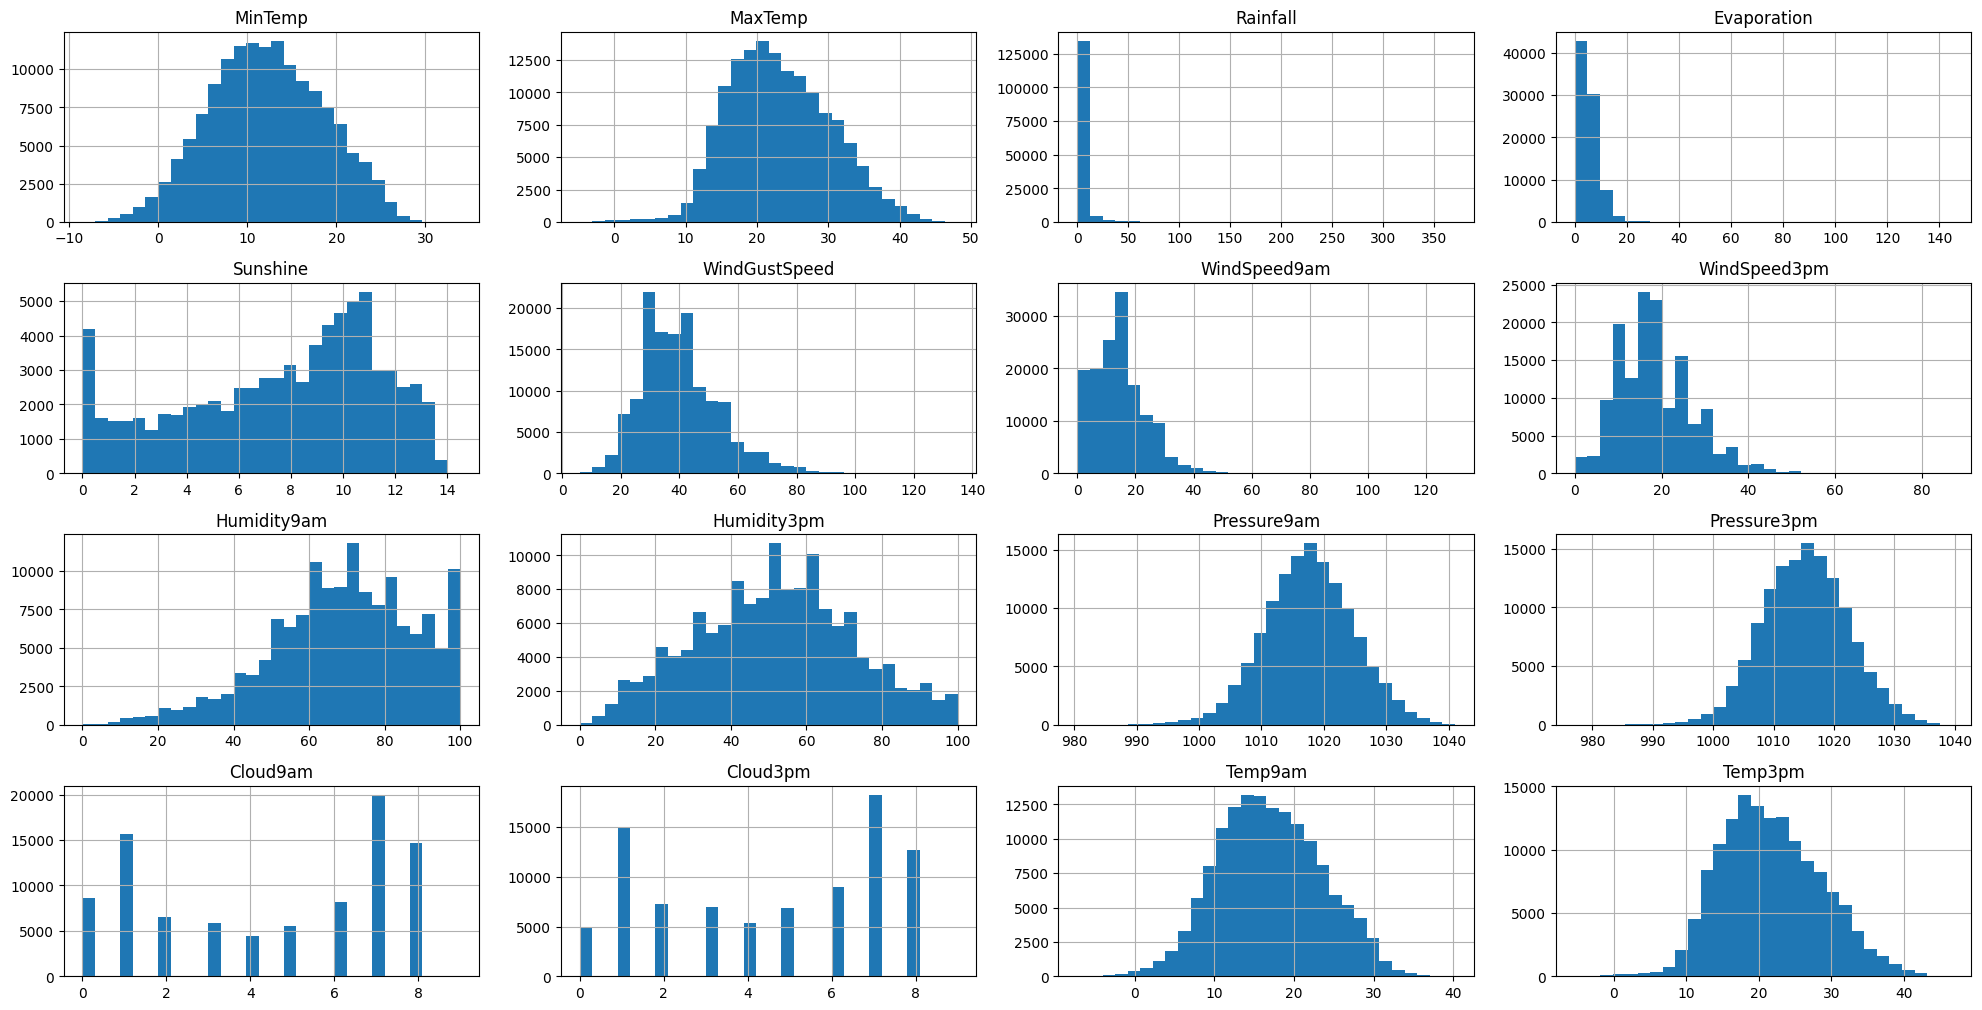

In [11]:
# Distribuição das variáveis numéricas
df.hist(bins=30, figsize=(20, 15), layout=(6, 4))
plt.tight_layout()
plt.show()

#### Variáveis Categóricas

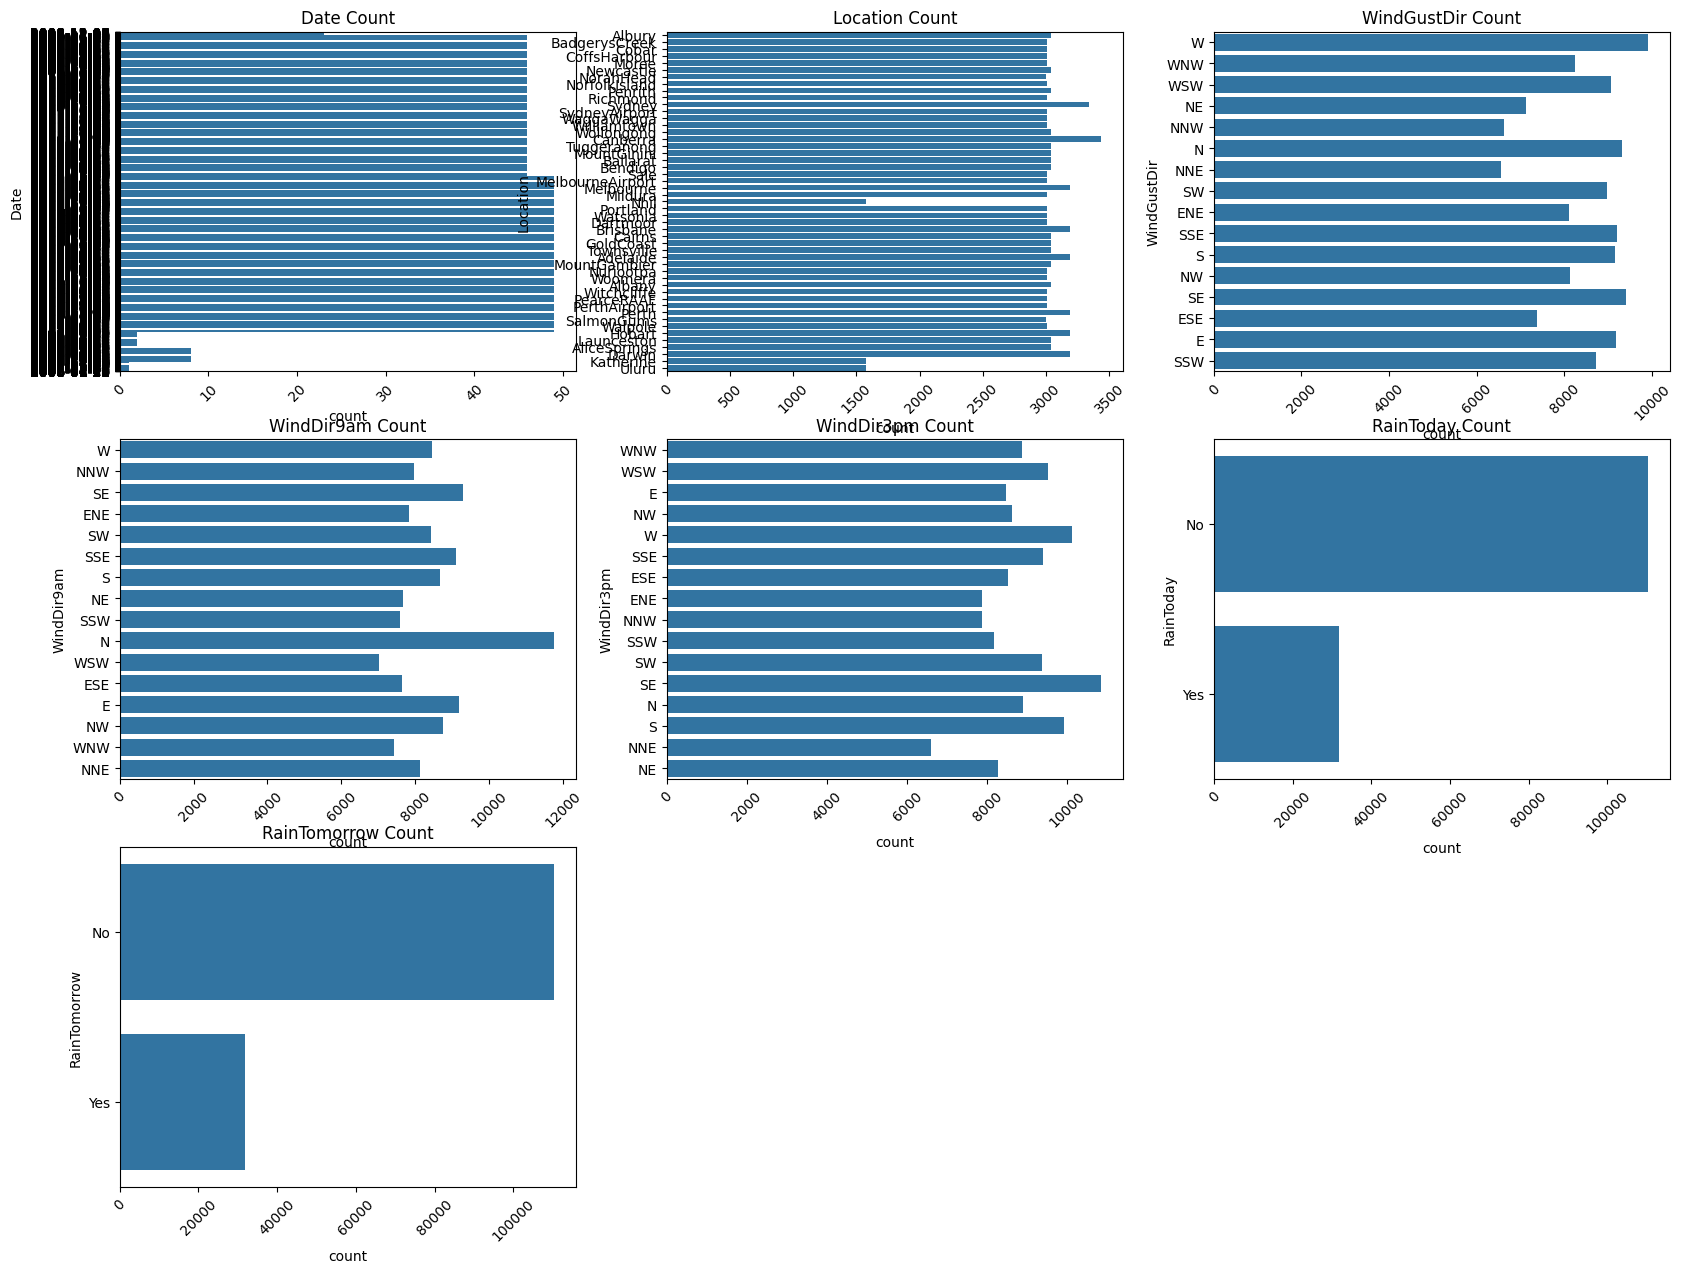

In [12]:
# Contagem das variáveis categóricas do DataFrame
plt.figure(figsize=(20, 15))
for i, column in enumerate(df.select_dtypes(include='object').columns, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, y=column)
    plt.title(f'{column} Count')
    plt.xticks(rotation=45)

## Analisando as variáveis Categóricas

#### Location

In [13]:
print("Locais do Dataset: {}\n".format(df.Location.unique()))
print("Locais diferentes no Dataset: {}\n".format(df.Location.nunique()))
print("Quantidade de vezes que cada cidade aparece no Dataset: {}".format(df.Location.value_counts()))

Locais do Dataset: ['Albury' 'BadgerysCreek' 'Cobar' 'CoffsHarbour' 'Moree' 'Newcastle'
 'NorahHead' 'NorfolkIsland' 'Penrith' 'Richmond' 'Sydney' 'SydneyAirport'
 'WaggaWagga' 'Williamtown' 'Wollongong' 'Canberra' 'Tuggeranong'
 'MountGinini' 'Ballarat' 'Bendigo' 'Sale' 'MelbourneAirport' 'Melbourne'
 'Mildura' 'Nhil' 'Portland' 'Watsonia' 'Dartmoor' 'Brisbane' 'Cairns'
 'GoldCoast' 'Townsville' 'Adelaide' 'MountGambier' 'Nuriootpa' 'Woomera'
 'Albany' 'Witchcliffe' 'PearceRAAF' 'PerthAirport' 'Perth' 'SalmonGums'
 'Walpole' 'Hobart' 'Launceston' 'AliceSprings' 'Darwin' 'Katherine'
 'Uluru']

Locais diferentes no Dataset: 49

Quantidade de vezes que cada cidade aparece no Dataset: Location
Canberra            3436
Sydney              3344
Darwin              3193
Melbourne           3193
Brisbane            3193
Adelaide            3193
Perth               3193
Hobart              3193
Albany              3040
MountGambier        3040
Ballarat            3040
Townsville          3040


A Austrália é um país de clima diversificado, com regiões que variam de desérticas a tropicais. A localização das estações meteorológicas é um fator importante a ser considerado, pois a distribuição das chuvas pode variar significativamente de uma região para outra. Dessa forma, a localização geográfica pode ser um fator determinante para a ocorrência de chuvas. Portanto, criou-se uma coluna binária que classifica as regiões de acordo com a zona climática a que pertencem, onde são atribuidos valores de 1, para regiões que pertencem a zonas chuvosas, ou 0, caso o contrário.

![Zonas climaticas da Australia](../imgs/zonas.png)

In [14]:
import pandas as pd
zona_chuvosa_map = {
    'Albury': 0, 'BadgerysCreek': 0, 'Cobar': 0, 'CoffsHarbour': 1, 'Moree': 0, 
    'Newcastle': 1, 'NorahHead': 1, 'NorfolkIsland': 1, 'Penrith': 0, 'Richmond': 0, 
    'Sydney': 1, 'SydneyAirport': 0, 'WaggaWagga': 0, 'Williamtown': 0, 'Wollongong': 1, 
    'Canberra': 0, 'Tuggeranong': 0, 'MountGinini': 1, 'Ballarat': 0, 'Bendigo': 0, 
    'Sale': 0, 'MelbourneAirport': 0, 'Melbourne': 0, 'Mildura': 0, 'Nhil': 0, 
    'Portland': 0, 'Watsonia': 0, 'Dartmoor': 0, 'Brisbane': 1, 'Cairns': 1, 
    'GoldCoast': 1, 'Townsville': 1, 'Adelaide': 0, 'MountGambier': 0, 'Nuriootpa': 0, 
    'Woomera': 0, 'Albany': 0, 'Witchcliffe': 0, 'PearceRAAF': 0, 'PerthAirport': 0, 
    'Perth': 0, 'SalmonGums': 0, 'Walpole': 0, 'Hobart': 1, 'Launceston': 1, 
    'AliceSprings': 0, 'Darwin': 1, 'Katherine': 1, 'Uluru': 0
}

# Adicionando a coluna 'zona_chuvosa' ao DataFrame
df['zona_chuvosa'] = df['Location'].map(zona_chuvosa_map)

# Exibindo as primeiras linhas do DataFrame após a alteração
print(df.head())


         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity3pm  Pressure9am  \
0           W           44.0          W  ...        22.0       1007.7   
1         WNW           44.0        NNW  ...        25.0       1010.6   
2         WSW           46.0          W  ...        30.0       1007.6   
3          NE           24.0         SE  ...        16.0       1017.6   
4           W           41.0        ENE  ...        33.0       1010.8   

   Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  RainTomorrow  \
0       1007.1   

### Analisando o comportamento da variável WindGustDir

In [15]:
print("Direções do Dataset: {}\n".format(df.WindGustDir.unique()))
print("Direções diferentes no Dataset: {}\n".format(df.WindGustDir.nunique()))
print("Quantidade de vezes que cada direção aparece no Dataset: {}".format(df.WindGustDir.value_counts()))

Direções do Dataset: ['W' 'WNW' 'WSW' 'NE' 'NNW' 'N' 'NNE' 'SW' nan 'ENE' 'SSE' 'S' 'NW' 'SE'
 'ESE' 'E' 'SSW']

Direções diferentes no Dataset: 16

Quantidade de vezes que cada direção aparece no Dataset: WindGustDir
W      9915
SE     9418
N      9313
SSE    9216
E      9181
S      9168
WSW    9069
SW     8967
SSW    8736
WNW    8252
NW     8122
ENE    8104
ESE    7372
NE     7133
NNW    6620
NNE    6548
Name: count, dtype: int64


## Visualizando Outliers com boxplots

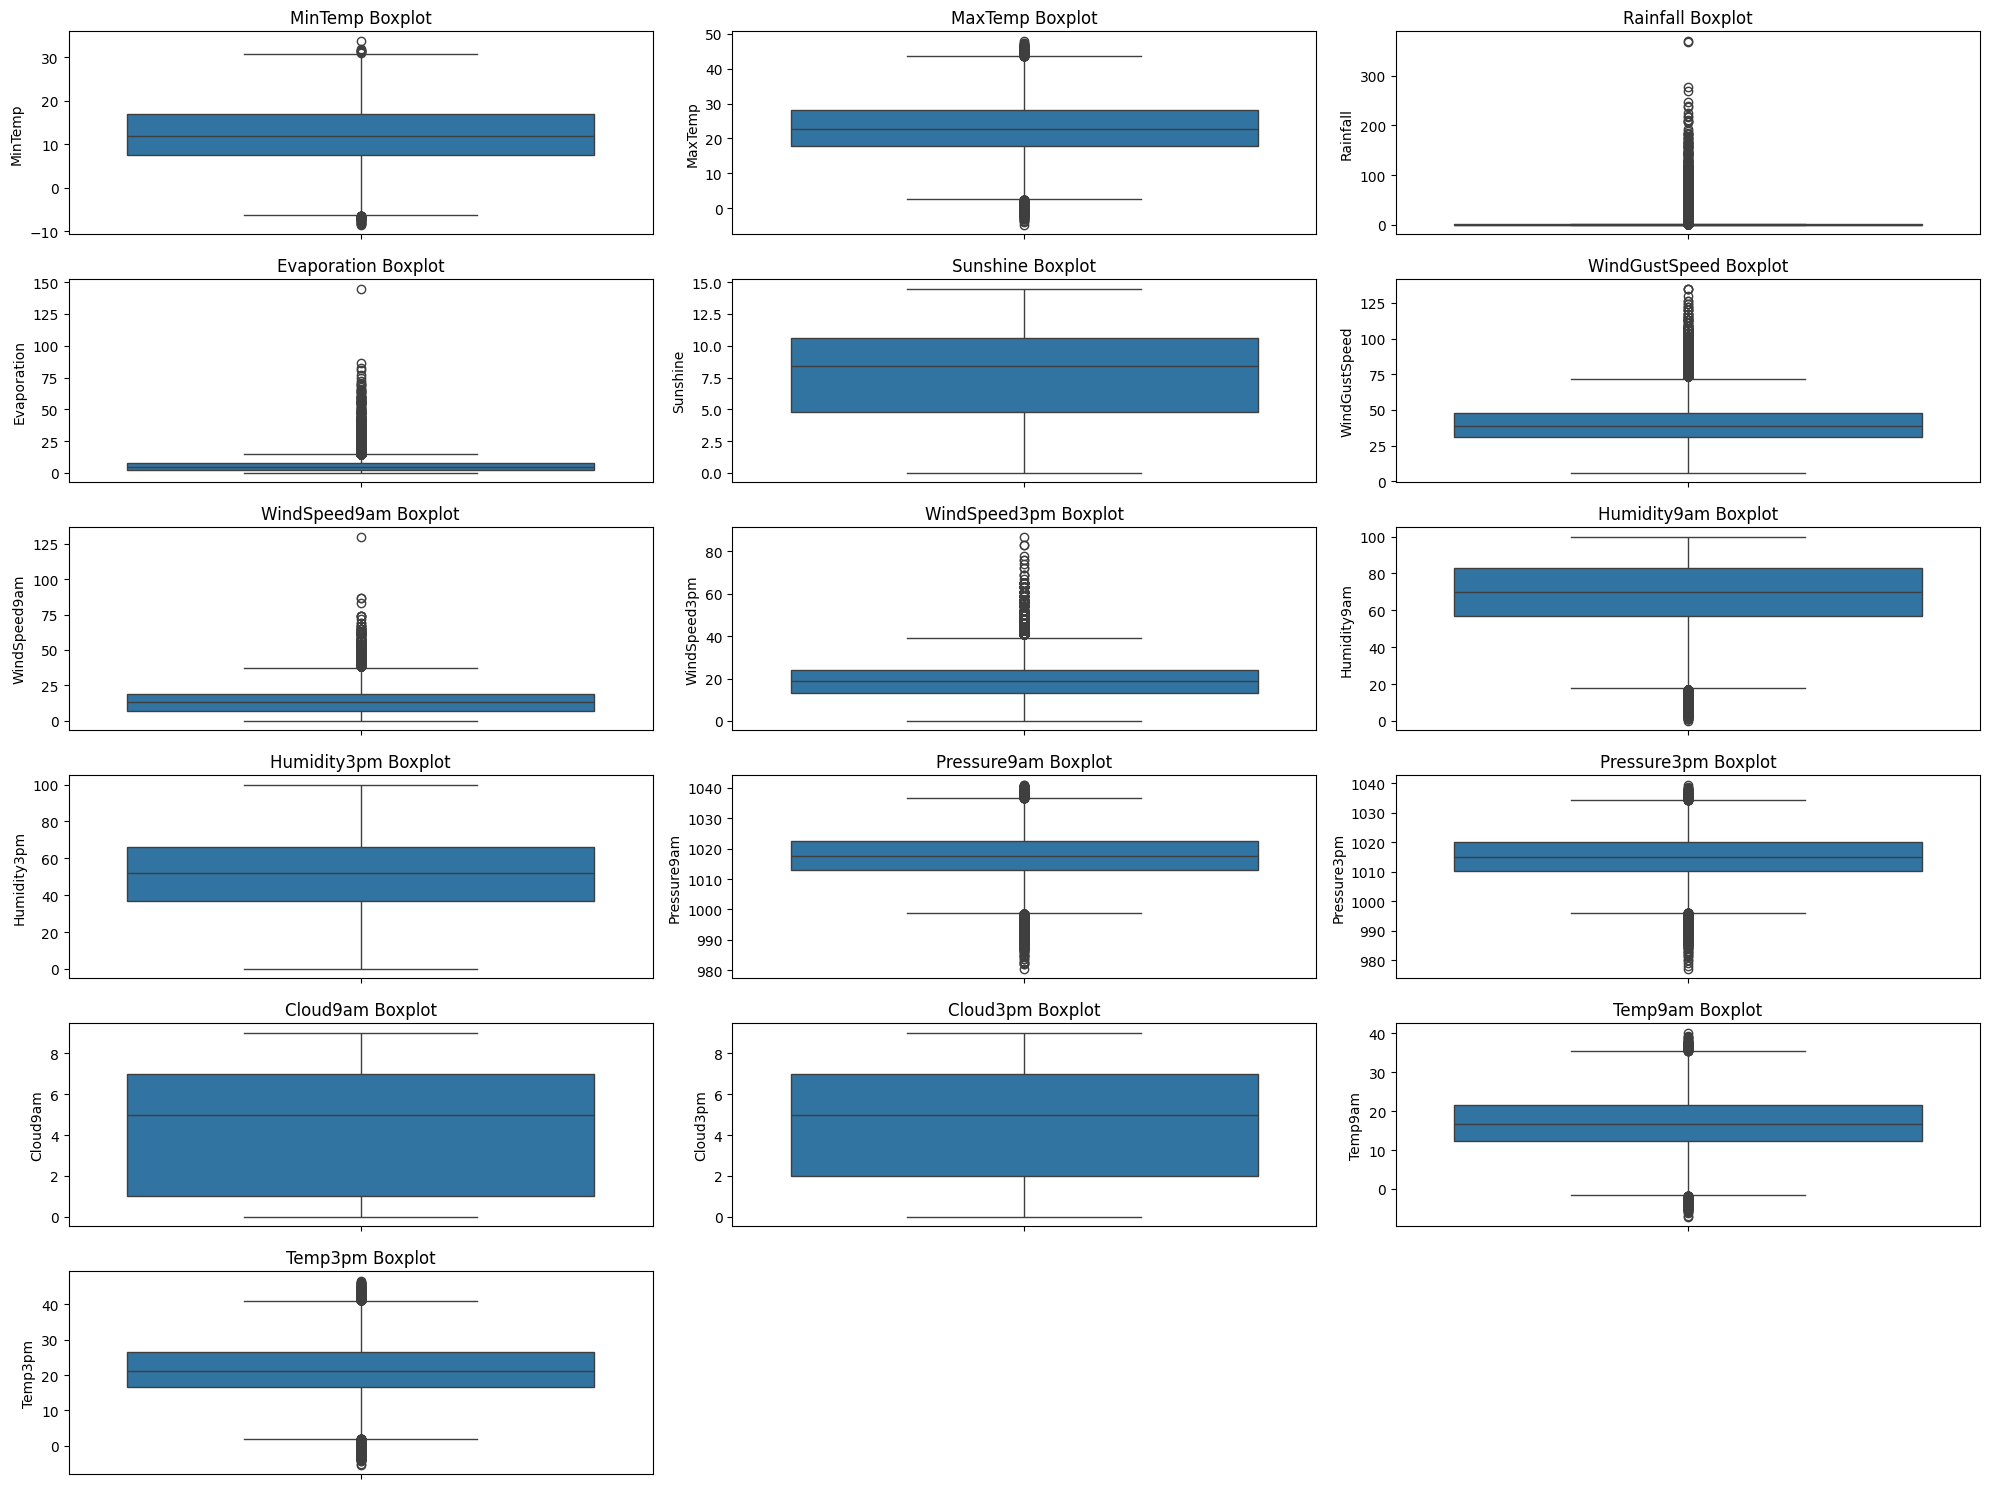

In [16]:
plt.figure(figsize=(20, 15))
num_columns = len(df.select_dtypes(include='float64').columns)
rows = (num_columns // 3) + 1

for i, column in enumerate(df.select_dtypes(include='float64').columns, 1):
    plt.subplot(rows, 3, i)
    sns.boxplot(data=df, y=column)
    plt.title(f'{column} Boxplot')

plt.tight_layout()
plt.show()

## Data Wrangling
Primeiro vamos formatar os dados da base de dados para prepará-lo para o modelo preditivo

## Tratamento dos dados vazios
### Dados Numéricos

In [17]:
#Visualizando as colunas numericas do dataset
numerical = [i for i in df.columns if df[i].dtype=='float64']
numerical

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm']

Para fazer o tratamento das colunas **MinTemp**, **MaxTemp**, **Humidity9am**, **Humidity3pm**, **Pressure9am**, **Pressure3pm**, **Temp9am**, **Temp3pm**, vamos substituir os dados ausentes pela média, uma vez que os dados apresentam uma distribuição normal.

In [18]:
#Substituindo os valores nulos pela média da coluna das colunas MinTemp, MaxTemp, Humidity9am, Humidity3pm, Pressure9am, Pressure3pm, Temp9am, Temp3pm
df['MinTemp'] = df['MinTemp'].fillna(df['MinTemp'].mean())
df['MaxTemp'] = df['MaxTemp'].fillna(df['MaxTemp'].mean())
df['Humidity9am'] = df['Humidity9am'].fillna(df['Humidity9am'].mean())
df['Humidity3pm'] = df['Humidity3pm'].fillna(df['Humidity3pm'].mean())
df['Pressure9am'] = df['Pressure9am'].fillna(df['Pressure9am'].mean())
df['Pressure3pm'] = df['Pressure3pm'].fillna(df['Pressure3pm'].mean())
df['Temp9am'] = df['Temp9am'].fillna(df['Temp9am'].mean())
df['Temp3pm'] = df['Temp3pm'].fillna(df['Temp3pm'].mean())

Para as colunas **Rainfall**, **Evaporation**, **Sunshine**, **WindGustSpeed**, **WindSpeed9am**, **WindSpeed3pm** vamos substituir os valores nulos pela mediana da coluna, já que os dados destes apresentam uma distribuição assimétrica

In [19]:
#Substituindo os valores nulos pela mediana da coluna das colunas WindGustSpeed, WindSpeed9am, WindSpeed3pm, Evaporation, Sunshine e Rainfall
df['WindGustSpeed'] = df['WindGustSpeed'].fillna(df['WindGustSpeed'].median())
df['WindSpeed9am'] = df['WindSpeed9am'].fillna(df['WindSpeed9am'].median())
df['WindSpeed3pm'] = df['WindSpeed3pm'].fillna(df['WindSpeed3pm'].median())
df['Evaporation'] = df['Evaporation'].fillna(df['Evaporation'].median())
df['Sunshine'] = df['Sunshine'].fillna(df['Sunshine'].median())
df['Rainfall'] = df['Rainfall'].fillna(df['Rainfall'].median())

Por fim, para as colunas **Cloud9am** e **Cloud3pm**, vamos substituir os valores vazios pela moda, uma vez que seus dados se apresentam discretos

In [20]:
#Substituindo os valores nulos pela moda da coluna das colunas cloud9am e cloud3pm
df['Cloud9am'] = df['Cloud9am'].fillna(df['Cloud9am'].mode()[0])
df['Cloud3pm'] = df['Cloud3pm'].fillna(df['Cloud3pm'].mode()[0])

### Dados Categóricos

As **Localizações** não apresentam dados vazios e portanto não precisam de tratamento. 
Para as colunas **WindGustDir**, **WindDir9am**, **WindDir3pm**, **RainToday** e **RainTomorrow** vamos substituir os valores vazios pelo valor mais frequente

In [21]:
df['WindGustDir'].fillna(df['WindGustDir'].mode()[0], inplace=True)
df['WindDir9am'].fillna(df['WindDir9am'].mode()[0], inplace=True)
df['WindDir3pm'].fillna(df['WindDir3pm'].mode()[0], inplace=True)
df['RainToday'].fillna(df['RainToday'].mode()[0], inplace=True)
df['RainTomorrow'].fillna(df['RainTomorrow'].mode()[0], inplace=True)

C:\Users\pichau\AppData\Local\Temp\ipykernel_22572\3401736357.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['WindGustDir'].fillna(df['WindGustDir'].mode()[0], inplace=True)
C:\Users\pichau\AppData\Local\Temp\ipykernel_22572\3401736357.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

Feito este tratamento, não deve haver mais dados vazios no dataset

In [22]:
df.isnull().sum()

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
zona_chuvosa     0
dtype: int64

Agora que não há mais dados ausentes, podemos ajustar os dados para que eles possam ser usados nos modelos preditivos.
A primeira coisa a ser feita é o mapeamento de colunas categóricas binárias (Sim e Não) para os valores 1 e 0 respectivamente.
Isso deverá ser feito nas colunas **RainToday** e **RainTomorrow**


In [23]:
# #Tratamento de variaveis categoricas 
df["RainToday"] = df["RainToday"].map({"Yes":1, "No":0})
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

Além disso, para as demais colunas categóricas precisamos codificar os dados.
Podemos começar separando as datas em 3 colunas numéricas representando **Dia**, **Mês** e **Ano** 

In [24]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

df.drop('Date', axis=1, inplace=True)  #Não precisamos mais da coluna Date uma vez que já extraímos as informações dela para outras colunas e o dataset está ordenado por data

Para as demais colunas categóricas vamos codificar usando a função **Label Encoder** do sklearn que transforma os valores categóricos em um número inteiro que representa aquele valor categorico

In [25]:
le =  LabelEncoder()
for i in df:
    if df[i].dtype=='object':
        df[i] = le.fit_transform(df[i])
    else:
        continue

Agora que todos os dados foram formatados, como podemos ver abaixo, não há mais o tipo *object* dentre as colunas

In [26]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 145460 entries, 45587 to 145459
Data columns (total 26 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Location       145460 non-null  int32  
 1   MinTemp        145460 non-null  float64
 2   MaxTemp        145460 non-null  float64
 3   Rainfall       145460 non-null  float64
 4   Evaporation    145460 non-null  float64
 5   Sunshine       145460 non-null  float64
 6   WindGustDir    145460 non-null  int32  
 7   WindGustSpeed  145460 non-null  float64
 8   WindDir9am     145460 non-null  int32  
 9   WindDir3pm     145460 non-null  int32  
 10  WindSpeed9am   145460 non-null  float64
 11  WindSpeed3pm   145460 non-null  float64
 12  Humidity9am    145460 non-null  float64
 13  Humidity3pm    145460 non-null  float64
 14  Pressure9am    145460 non-null  float64
 15  Pressure3pm    145460 non-null  float64
 16  Cloud9am       145460 non-null  float64
 17  Cloud3pm       145460 non-null

Agora que não temos mais dados categóricos, podemos analisar a correlação entre as variáveis

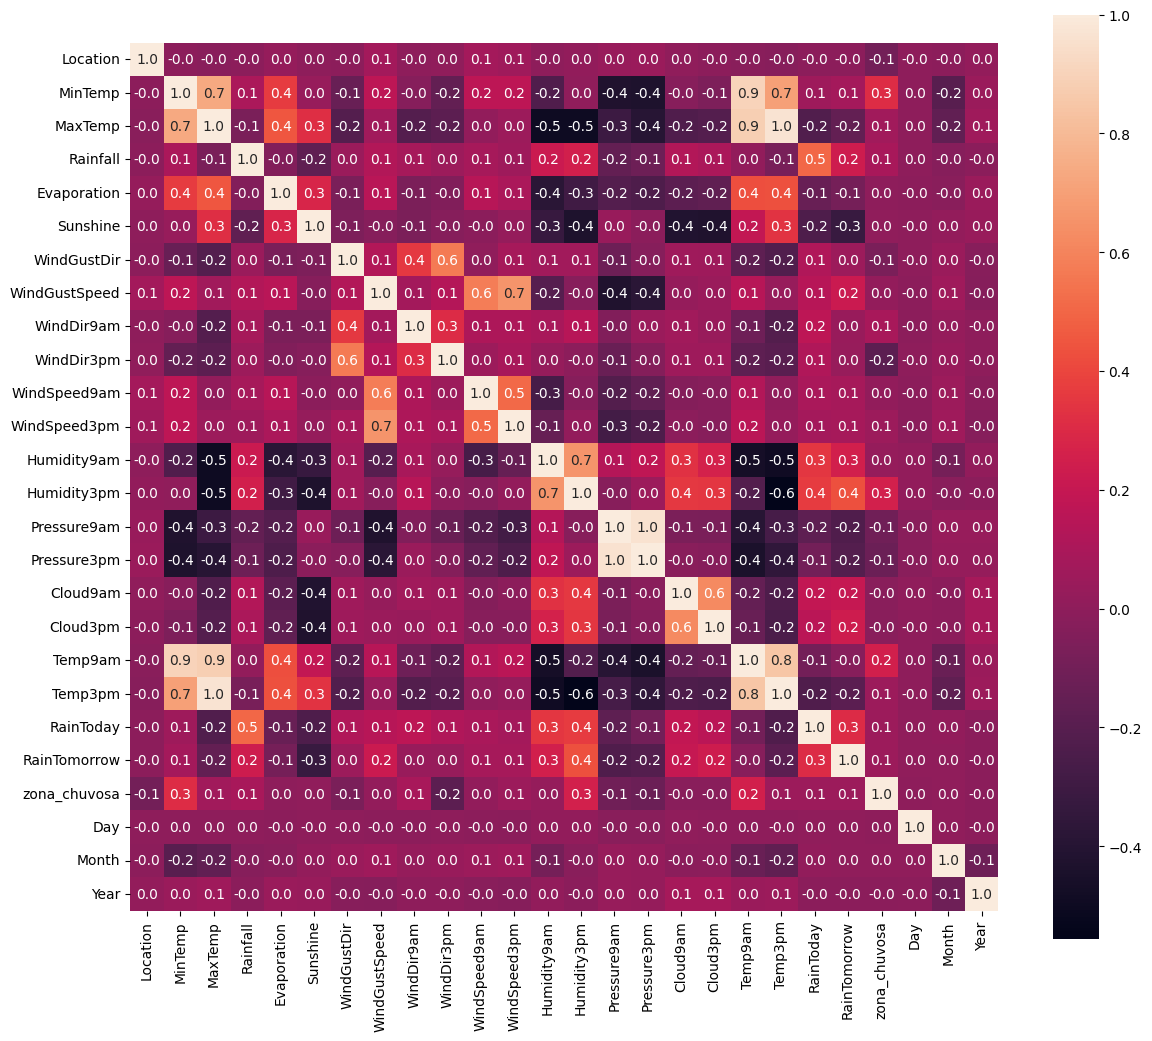

In [27]:
corr = df.corr()
plt.figure(figsize=(14,12))
ax = sns.heatmap(corr, square=True, annot=True, fmt='.1f')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)          
plt.show()

In [28]:
df.head()

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,zona_chuvosa,Day,Month,Year
45587,9,8.0,24.3,0.0,3.4,6.3,7,30.0,12,7,...,7.0,7.0,14.4,23.6,0,1,0,1,11,2007
45588,9,14.0,26.9,3.6,4.4,9.7,1,39.0,0,13,...,5.0,3.0,17.5,25.7,1,1,0,2,11,2007
45589,9,13.7,23.4,3.6,5.8,3.3,7,85.0,3,5,...,8.0,7.0,15.4,20.2,1,1,0,3,11,2007
45590,9,13.3,15.5,39.8,7.2,9.1,7,54.0,14,13,...,2.0,7.0,13.5,14.1,1,1,0,4,11,2007
45591,9,7.6,16.1,2.8,5.6,10.6,10,50.0,10,2,...,7.0,7.0,11.1,15.4,1,0,0,5,11,2007


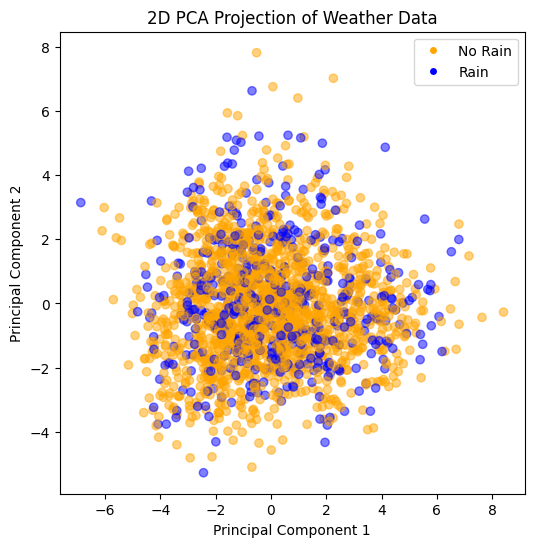

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Assume 'df' is your preprocessed DataFrame from the notebook
X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA for 2D projection
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame for plotting
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['class'] = y

# Sample 2000 points for visualization (to avoid overcrowding)
df_sample = df_pca.sample(n=2000, random_state=42)

# Plot similar to the attached image style
plt.figure(figsize=(6, 6))
colors = {0: 'orange', 1: 'blue'}
plt.scatter(df_sample['PC1'], df_sample['PC2'], c=df_sample['class'].map(colors), alpha=0.5)
plt.title('2D PCA Projection of Weather Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', label='No Rain'), 
                    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', label='Rain')])
plt.show()

In [32]:
# --- 1. Carregamento ---------------------------------------------------------
 
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap
from umap import UMAP           # pip install umap-learn
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook já tem o DataFrame 'df'; se preferir CSV:
# df = pd.read_csv("weatherAUS.csv")

target = 'RainTomorrow'
num_cols = df.select_dtypes('number').columns.tolist()
X = df[num_cols].dropna()                  # remove NaNs
y = df.loc[X.index, target].map({'No':0,'Yes':1})  # laranja / azul

X_std = StandardScaler().fit_transform(X)

# --- 2. Reduções de dimensionalidade ----------------------------------------
reducers = {
    'PCA (2 D)':        PCA(n_components=2, random_state=42),
    't-SNE':            TSNE(n_components=2, perplexity=40, random_state=42),
    'UMAP':             UMAP(n_components=2, random_state=42),
    'Isomap':           Isomap(n_components=2, n_neighbors=12)
}

embeddings = {name: r.fit_transform(X_std) for name, r in reducers.items()}

# --- 3. Plot estilo imagem anexa --------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(10,10))
axes = axes.ravel()
palette = {0:'#FF8C00', 1:'#0066CC'}      # laranja / azul

for ax, (name, Z) in zip(axes, embeddings.items()):
    sns.scatterplot(x=Z[:,0], y=Z[:,1], hue=y, palette=palette,
                    s=12, linewidth=0, alpha=0.8, ax=ax, legend=False)
    ax.set_title(name, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel(''); ax.set_ylabel('')
    ax.spines[['top','right','left','bottom']].set_visible(False)

plt.tight_layout()
plt.show()

TypeError: check_array() got an unexpected keyword argument 'ensure_all_finite'

Class weights: No Rain=0.64, Rain=2.28
Dataset: (145460, 25) | Histórico: 2007-11-01 00:00:00 a 2015-11-10 00:00:00 | Teste: 2015-11-10 00:00:00 a 2017-06-25 00:00:00

--- CV com Janela Móvel Expanding (MLP + Weighted Loss) ---
  Ep 1: Train Loss 0.6725 | Val Loss 0.6732 | Acc 0.599/0.600
  Ep 50: Train Loss 0.5002 | Val Loss 0.5363 | Acc 0.771/0.734
  Ep 100: Train Loss 0.4728 | Val Loss 0.4948 | Acc 0.781/0.757
  Ep 150: Train Loss 0.4637 | Val Loss 0.4771 | Acc 0.788/0.770
  Early stop na época 187
Fold 1: Final Val Acc=0.7760 | Best Val Loss=0.4682
  - Datas Val: 2010-04-01 a 2010-12-10
  Ep 1: Train Loss 0.7098 | Val Loss 0.7155 | Acc 0.430/0.423
  Early stop na época 50
Fold 2: Final Val Acc=0.7574 | Best Val Loss=0.5008
  - Datas Val: 2011-09-19 a 2012-05-29
  Ep 1: Train Loss 0.7426 | Val Loss 0.7533 | Acc 0.320/0.252
  Ep 50: Train Loss 0.4876 | Val Loss 0.4959 | Acc 0.771/0.762
  Early stop na época 84
Fold 3: Final Val Acc=0.7736 | Best Val Loss=0.4768
  - Datas Val: 2013-04

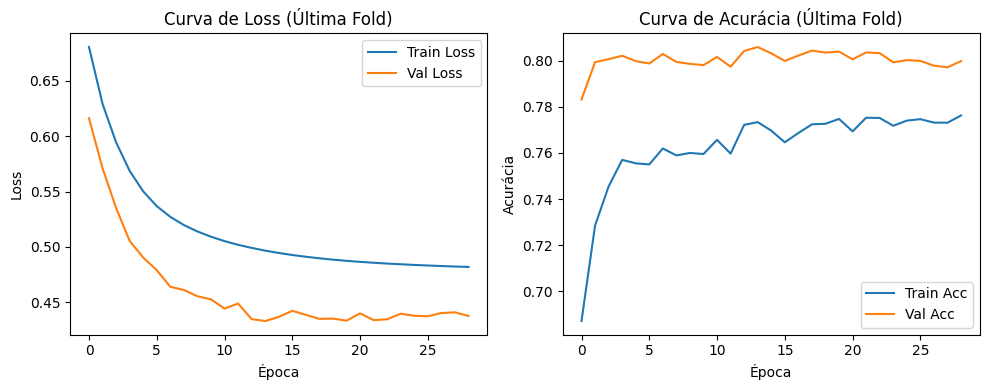

Final Ep 50: Train Loss 0.4823 | Val Loss 0.4418 | Acc 0.774/0.794
Early stop final na época 81


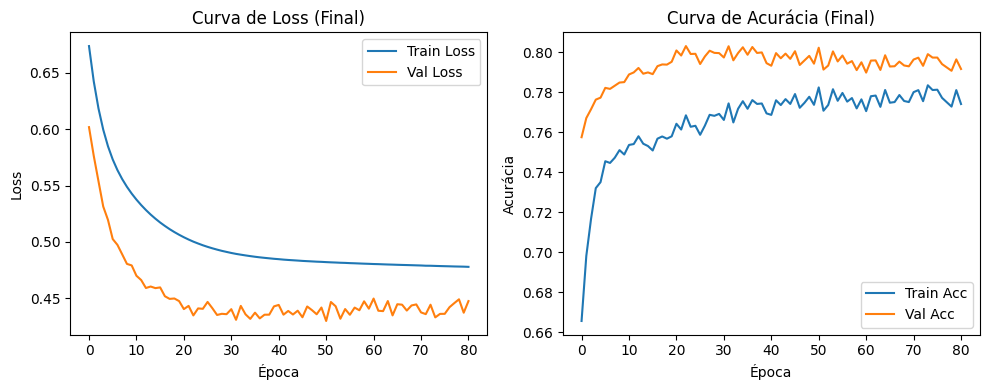


📊 MÉTRICAS FINAIS (Teste)
Acurácia : 0.7957
Precisão (Rain): 0.5245
Recall (Rain): 0.6813
F1-score (Rain): 0.5927
Log-Loss : 0.4515

Classification Report:
               precision    recall  f1-score   support

     No Rain       0.90      0.83      0.86     22745
        Rain       0.52      0.68      0.59      6347

    accuracy                           0.80     29092
   macro avg       0.71      0.75      0.73     29092
weighted avg       0.82      0.80      0.80     29092



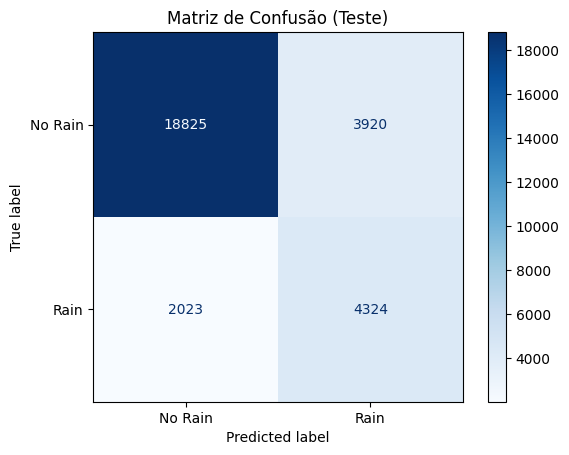

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, log_loss
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------------
# 0) Preparação do Dataset (Todas Features, Temporal por Date)
# ------------------------------------------------------------------
df = df.copy()
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])

# Sort por Date apenas (global temporal)
df_sorted = df.sort_values('Date').reset_index(drop=True)

# Features: Todas exceto 'RainTomorrow' e 'Date'
feature_cols = [col for col in df_sorted.columns if col not in ['RainTomorrow', 'Date']]
X = df_sorted[feature_cols].values  # (145460, 25)
y = df_sorted['RainTomorrow'].values  # 0/1

# Normaliza para [0,1]
scaler = StandardScaler()
X_norm = scaler.fit_transform(X)
X_scaled = (X_norm - X_norm.min(axis=0)) / (X_norm.max(axis=0) - X_norm.min(axis=0) + 1e-8)

# Map y para indices (binário)
classes = np.sort(np.unique(y))
class_to_idx = {c: i for i, c in enumerate(classes)}
Y = np.array([class_to_idx[label] for label in y], dtype=int)
num_classes = len(classes)  # 2

# Class weights para imbalance
n_no_rain = np.sum(Y == 0)
n_rain = np.sum(Y == 1)
weight_no_rain = len(Y) / (2 * n_no_rain)
weight_rain = len(Y) / (2 * n_rain)
class_weights = np.array([weight_no_rain, weight_rain])
print(f"Class weights: No Rain={weight_no_rain:.2f}, Rain={weight_rain:.2f}")

# Histórico 80% para CV/Train, 20% teste recente
cutoff_idx = int(0.8 * len(X_scaled))
X_hist = X_scaled[:cutoff_idx]
Y_hist = Y[:cutoff_idx]
X_test_full = X_scaled[cutoff_idx:]
Y_test_full = Y[cutoff_idx:]
dates_hist = df_sorted['Date'][:cutoff_idx]
dates_test = df_sorted['Date'][cutoff_idx:]

print(f"Dataset: {X_scaled.shape} | Histórico: {dates_hist.min()} a {dates_hist.max()} | Teste: {dates_test.min()} a {dates_test.max()}")

def one_hot(y, K):
    eye = np.eye(K, dtype=float)
    return eye[y]

# ------------------------------------------------------------------
# 1) Janela Móvel Expanding (5 Folds, Fix para Último Fold)
# ------------------------------------------------------------------
fold_fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
val_size = int(0.1 * len(X_hist))
cv_scores = []
last_train_losses, last_val_losses = [], []
last_train_accs, last_val_accs = [], []

print("\n--- CV com Janela Móvel Expanding (MLP + Weighted Loss) ---")
for fold, train_frac in enumerate(fold_fractions):
    train_end = int(train_frac * len(X_hist))
    
    if train_frac < 1.0:
        val_start = train_end
        val_end = min(val_start + val_size, len(X_hist))
    else:
        # Para último fold: val nos últimos val_size do histórico
        val_start = len(X_hist) - val_size
        val_end = len(X_hist)
        train_end = val_start  # Treina até antes da val
    
    X_train_fold = X_hist[:train_end]
    Y_train_fold = Y_hist[:train_end]
    X_val_fold = X_hist[val_start:val_end]
    Y_val_fold = Y_hist[val_start:val_end]
    
    val_dates_start = dates_hist.iloc[val_start].date()
    val_dates_end = dates_hist.iloc[val_end - 1].date()
    
    N_fold = len(X_train_fold)
    D = X_train_fold.shape[1]
    
    # Inicialização
    rng = np.random.default_rng(42 + fold)
    H1, H2 = 64, 32
    W1 = rng.normal(0, 1, (H1, D)) / np.sqrt(D)
    b1 = np.zeros(H1)
    W2 = rng.normal(0, 1, (H2, H1)) / np.sqrt(H1)
    b2 = np.zeros(H2)
    W3 = rng.normal(0, 1, (num_classes, H2)) / np.sqrt(H2)
    b3 = np.zeros(num_classes)
    
    def tanh(x): return np.tanh(x)
    def softmax(x):
        x = x - x.max(axis=1, keepdims=True)
        e = np.exp(x)
        return e / e.sum(axis=1, keepdims=True)
    
    def forward(X):
        h1 = tanh(X @ W1.T + b1)
        h2 = tanh(h1 @ W2.T + b2)
        yhat = softmax(h2 @ W3.T + b3)
        return yhat
    
    # Treino
    lr = 0.001
    epochs = 200
    batch = 128
    lambda_l2 = 1e-4
    patience = 15
    
    Y_train_oh = one_hot(Y_train_fold, num_classes)
    train_losses = []; val_losses = []; train_accs = []; val_accs = []
    best_val = np.inf; bad_epochs = 0
    best_W1, best_b1 = W1.copy(), b1.copy()
    best_W2, best_b2 = W2.copy(), b2.copy()
    best_W3, best_b3 = W3.copy(), b3.copy()
    
    for ep in range(1, epochs + 1):
        idx = rng.permutation(N_fold)
        X_shuf = X_train_fold[idx]
        Y_shuf = Y_train_oh[idx]
        
        epoch_loss = 0
        for i in range(0, N_fold, batch):
            xb = X_shuf[i:i+batch]
            yb = Y_shuf[i:i+batch]
            B = xb.shape[0]
            
            # Forward
            h1 = tanh(xb @ W1.T + b1)
            h2 = tanh(h1 @ W2.T + b2)
            yhat = softmax(h2 @ W3.T + b3)
            
            # Weighted CE
            sample_weights = np.sum(yb * class_weights, axis=1)
            ce = -np.sum(yb * np.log(yhat + 1e-9), axis=1)
            loss_ce = np.mean(ce * sample_weights)
            l2_term = lambda_l2 * (np.sum(W1**2) + np.sum(W2**2) + np.sum(W3**2))
            loss = loss_ce + l2_term
            epoch_loss += loss * B / N_fold
            
            # Backward weighted
            d3 = (yhat - yb) / B
            d3_weighted = d3 * sample_weights[:, np.newaxis]
            gW3 = d3_weighted.T @ h2 + 2 * lambda_l2 * W3
            gb3 = d3_weighted.sum(axis=0)
            dh2 = d3_weighted @ W3
            dz2 = dh2 * (1 - h2**2)
            gW2 = dz2.T @ h1 + 2 * lambda_l2 * W2
            gb2 = dz2.sum(axis=0)
            dh1 = dz2 @ W2
            dz1 = dh1 * (1 - h1**2)
            gW1 = dz1.T @ xb + 2 * lambda_l2 * W1
            gb1 = dz1.sum(axis=0)
            
            # Updates
            W1 -= lr * gW1
            b1 -= lr * gb1
            W2 -= lr * gW2
            b2 -= lr * gb2
            W3 -= lr * gW3
            b3 -= lr * gb3
        
        # Val
        yhat_train = forward(X_train_fold)
        train_acc = (np.argmax(yhat_train, axis=1) == Y_train_fold).mean()
        yhat_val = forward(X_val_fold)
        Y_val_oh = one_hot(Y_val_fold, num_classes)
        val_ce = -np.mean(np.sum(Y_val_oh * np.log(yhat_val + 1e-9), axis=1))
        val_acc = (np.argmax(yhat_val, axis=1) == Y_val_fold).mean()
        val_loss = val_ce
        
        train_losses.append(epoch_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        if val_loss < best_val - 1e-6:
            best_val = val_loss
            bad_epochs = 0
            best_W1, best_b1 = W1.copy(), b1.copy()
            best_W2, best_b2 = W2.copy(), b2.copy()
            best_W3, best_b3 = W3.copy(), b3.copy()
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"  Early stop na época {ep}")
                break
        
        if ep % 50 == 0 or ep == 1:
            print(f"  Ep {ep}: Train Loss {epoch_loss:.4f} | Val Loss {val_loss:.4f} | Acc {train_acc:.3f}/{val_acc:.3f}")
    
    # Restore best
    W1, b1, W2, b2, W3, b3 = best_W1, best_b1, best_W2, best_b2, best_W3, best_b3
    
    # Final val acc
    yhat_val_final = forward(X_val_fold)
    val_acc_final = (np.argmax(yhat_val_final, axis=1) == Y_val_fold).mean()
    cv_scores.append(val_acc_final)
    
    print(f"Fold {fold+1}: Final Val Acc={val_acc_final:.4f} | Best Val Loss={best_val:.4f}")
    print(f"  - Datas Val: {val_dates_start} a {val_dates_end}")
    
    if fold == 4:
        last_train_losses, last_val_losses = train_losses, val_losses
        last_train_accs, last_val_accs = train_accs, val_accs

print(f"\nMédia CV - Val Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores)*2:.4f})")

# Plot curvas da última fold
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(last_train_losses, label="Train Loss")
plt.plot(last_val_losses, label="Val Loss")
plt.xlabel("Época"); plt.ylabel("Loss"); plt.title("Curva de Loss (Última Fold)")
plt.legend()

plt.subplot(1,2,2)
plt.plot(last_train_accs, label="Train Acc")
plt.plot(last_val_accs, label="Val Acc")
plt.xlabel("Época"); plt.ylabel("Acurácia"); plt.title("Curva de Acurácia (Última Fold)")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 2) Treino Final Completo (Full Histórico, Weighted Loss, Val Interna)
# ------------------------------------------------------------------
N_final = len(X_hist)
D_final = X_hist.shape[1]
Y_final = Y_hist
Y_final_oh = one_hot(Y_final, num_classes)

rng_final = np.random.default_rng(42)
H1, H2 = 64, 32
W1 = rng_final.normal(0, 1, (H1, D_final)) / np.sqrt(D_final)
b1 = np.zeros(H1)
W2 = rng_final.normal(0, 1, (H2, H1)) / np.sqrt(H1)
b2 = np.zeros(H2)
W3 = rng_final.normal(0, 1, (num_classes, H2)) / np.sqrt(H2)
b3 = np.zeros(num_classes)

epochs_final = 500
batch = 128
lambda_l2 = 1e-4
lr = 0.001
patience_final = 30

# Val interna: últimos 20% do histórico para early stop
val_split_final = int(0.2 * N_final)
X_train_final = X_hist[:-val_split_final]
Y_train_final = Y_final[:-val_split_final]
Y_train_final_oh = one_hot(Y_train_final, num_classes)
X_val_final = X_hist[-val_split_final:]
Y_val_final = Y_final[-val_split_final:]
N_train_final = len(X_train_final)

train_losses_final = []; val_losses_final = []; train_accs_final = []; val_accs_final = []

best_val_final = np.inf; bad_epochs_final = 0
best_W1_final, best_b1_final = W1.copy(), b1.copy()
best_W2_final, best_b2_final = W2.copy(), b2.copy()
best_W3_final, best_b3_final = W3.copy(), b3.copy()

for ep in range(1, epochs_final + 1):
    idx = rng_final.permutation(N_train_final)
    X_shuf_final = X_train_final[idx]
    Y_shuf_final = Y_train_final_oh[idx]
    
    epoch_loss = 0
    for i in range(0, N_train_final, batch):
        xb = X_shuf_final[i:i+batch]
        yb = Y_shuf_final[i:i+batch]
        B = xb.shape[0]
        
        # Forward
        h1 = tanh(xb @ W1.T + b1)
        h2 = tanh(h1 @ W2.T + b2)
        yhat = softmax(h2 @ W3.T + b3)
        
        # Weighted loss
        sample_weights = np.sum(yb * class_weights, axis=1)
        ce = -np.sum(yb * np.log(yhat + 1e-9), axis=1)
        loss_ce = np.mean(ce * sample_weights)
        l2_term = lambda_l2 * (np.sum(W1**2) + np.sum(W2**2) + np.sum(W3**2))
        loss = loss_ce + l2_term
        epoch_loss += loss * B / N_train_final
        
        # Backward
        d3 = (yhat - yb) / B
        d3_weighted = d3 * sample_weights[:, np.newaxis]
        gW3 = d3_weighted.T @ h2 + 2 * lambda_l2 * W3
        gb3 = d3_weighted.sum(axis=0)
        dh2 = d3_weighted @ W3
        dz2 = dh2 * (1 - h2**2)
        gW2 = dz2.T @ h1 + 2 * lambda_l2 * W2
        gb2 = dz2.sum(axis=0)
        dh1 = dz2 @ W2
        dz1 = dh1 * (1 - h1**2)
        gW1 = dz1.T @ xb + 2 * lambda_l2 * W1
        gb1 = dz1.sum(axis=0)
        
        # Updates
        W1 -= lr * gW1
        b1 -= lr * gb1
        W2 -= lr * gW2
        b2 -= lr * gb2
        W3 -= lr * gW3
        b3 -= lr * gb3
    
    # Val interna
    yhat_train_final = forward(X_train_final)
    train_acc_final = (np.argmax(yhat_train_final, axis=1) == Y_train_final).mean()
    yhat_val_final = forward(X_val_final)
    Y_val_oh_final = one_hot(Y_val_final, num_classes)
    val_ce_final = -np.mean(np.sum(Y_val_oh_final * np.log(yhat_val_final + 1e-9), axis=1))
    val_acc_final = (np.argmax(yhat_val_final, axis=1) == Y_val_final).mean()
    val_loss_final = val_ce_final
    
    train_losses_final.append(epoch_loss)
    val_losses_final.append(val_loss_final)
    train_accs_final.append(train_acc_final)
    val_accs_final.append(val_acc_final)
    
    if val_loss_final < best_val_final - 1e-6:
        best_val_final = val_loss_final
        bad_epochs_final = 0
        best_W1_final, best_b1_final = W1.copy(), b1.copy()
        best_W2_final, best_b2_final = W2.copy(), b2.copy()
        best_W3_final, best_b3_final = W3.copy(), b3.copy()
    else:
        bad_epochs_final += 1
        if bad_epochs_final >= patience_final:
            print(f"Early stop final na época {ep}")
            break
    
    if ep % 50 == 0:
        print(f"Final Ep {ep}: Train Loss {epoch_loss:.4f} | Val Loss {val_loss_final:.4f} | Acc {train_acc_final:.3f}/{val_acc_final:.3f}")

# Restore best final
W1, b1, W2, b2, W3, b3 = best_W1_final, best_b1_final, best_W2_final, best_b2_final, best_W3_final, best_b3_final

# Plot curvas final
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses_final, label="Train Loss")
plt.plot(val_losses_final, label="Val Loss")
plt.xlabel("Época"); plt.ylabel("Loss"); plt.title("Curva de Loss (Final)")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs_final, label="Train Acc")
plt.plot(val_accs_final, label="Val Acc")
plt.xlabel("Época"); plt.ylabel("Acurácia"); plt.title("Curva de Acurácia (Final)")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 3) Avaliação Final no Teste
# ------------------------------------------------------------------
yhat_test = forward(X_test_full)
y_pred_test = np.argmax(yhat_test, axis=1)

acc_test = accuracy_score(Y_test_full, y_pred_test)
prec_test = precision_score(Y_test_full, y_pred_test, average='binary', pos_label=1)
rec_test = recall_score(Y_test_full, y_pred_test, average='binary', pos_label=1)
f1_test = f1_score(Y_test_full, y_pred_test, average='binary', pos_label=1)
loss_test = log_loss(one_hot(Y_test_full, num_classes), yhat_test)

print("\n📊 MÉTRICAS FINAIS (Teste)")
print(f"Acurácia : {acc_test:.4f}")
print(f"Precisão (Rain): {prec_test:.4f}")
print(f"Recall (Rain): {rec_test:.4f}")
print(f"F1-score (Rain): {f1_test:.4f}")
print(f"Log-Loss : {loss_test:.4f}")

print("\nClassification Report:\n", classification_report(Y_test_full, y_pred_test, target_names=['No Rain', 'Rain']))

# ------------------------------------------------------------------
# 4) Matriz de Confusão
# ------------------------------------------------------------------
cm = confusion_matrix(Y_test_full, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rain', 'Rain'])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão (Teste)")
plt.show()

In [34]:
df.columns

Index(['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow', 'zona_chuvosa', 'Day', 'Month',
       'Year'],
      dtype='object')